# Lab 066 · How TabICL builds and uses context

[Lesson](../lessons/0066-tabicl-column-row-attention.html) · [Reference](../reference/0066-tabicl-column-row-attention.html) · [Reproduction contract](l066-reproduction.md)

**Route:** retrieve → explain → predict → implement → CHECK → inspect evidence → EXIT. PROVIDED cells are readable implementation and peripheral support. TODOs contain your load-bearing code; CHECKs give immediate diagnostic feedback. Complete the code before revealing teacher solutions. Core study: 35–50 minutes; lab: 45–75 minutes plus explicitly gated larger runs.

**Before reading:** Does inducing-point column attention make every stage of TabICL linear in rows? Write your answer and justify the information boundary. Then recall one older lesson that could expose an error in this experiment.

**Evidence contract:** numerical figures labeled author-reference come from committed author measurements. They are not outputs of your current kernel. Reduced model mechanisms, pretrained reference inference, frozen-result reanalysis and paper reproduction are different tracks. Every track states its scope below.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## Separate representation construction from in-context prediction

Your goal is to implement TabICL's inducing-vector computation, trace the full prediction route and measure what a larger labeled context buys. Read [Qu et al., Sections 3–4](https://arxiv.org/html/2502.05564v1). TabICL first builds distribution-aware cell and row representations, then applies a dataset-level in-context learner. This separation changes the cost structure compared with repeatedly alternating full table axes.

The paper reports experiments at much larger context sizes than early TabPFN. Those sizes are measured/model regimes, not unconditional guarantees that every table of that row count will fit any GPU. Feature count, query batching, number of ensemble views, precision and available memory still matter. The local timing intervention reaches 540 context rows; the 500,000-row experiment is explicitly unrun.

## Model architecture: column, row, dataset

Start with N rows and F scalar features. A shared column encoder processes each feature's collection of values, using labeled-training rows as the source of distribution information. It generates a hidden vector for each cell. A row Transformer mixes a row's feature vectors and learned summary tokens; concatenated summary outputs form a fixed-width row representation. A final Transformer adds encoded labels for context rows, lets queries attend to context, and feeds query outputs through a class-probability head.

In the original paper configuration, the column and row hidden width is 128; four row summary tokens produce width 512 for the dataset-level learner. The paper uses multiple induced-attention blocks, row-attention layers and a 12-layer final learner. Our visible implementation isolates the inducing-attention and distribution-conditioned affine mechanisms. The actual measured scores use the separately pinned pretrained v1.1 checkpoint, not those untrained reduced blocks.

<div style="overflow-x:auto;max-width:100%">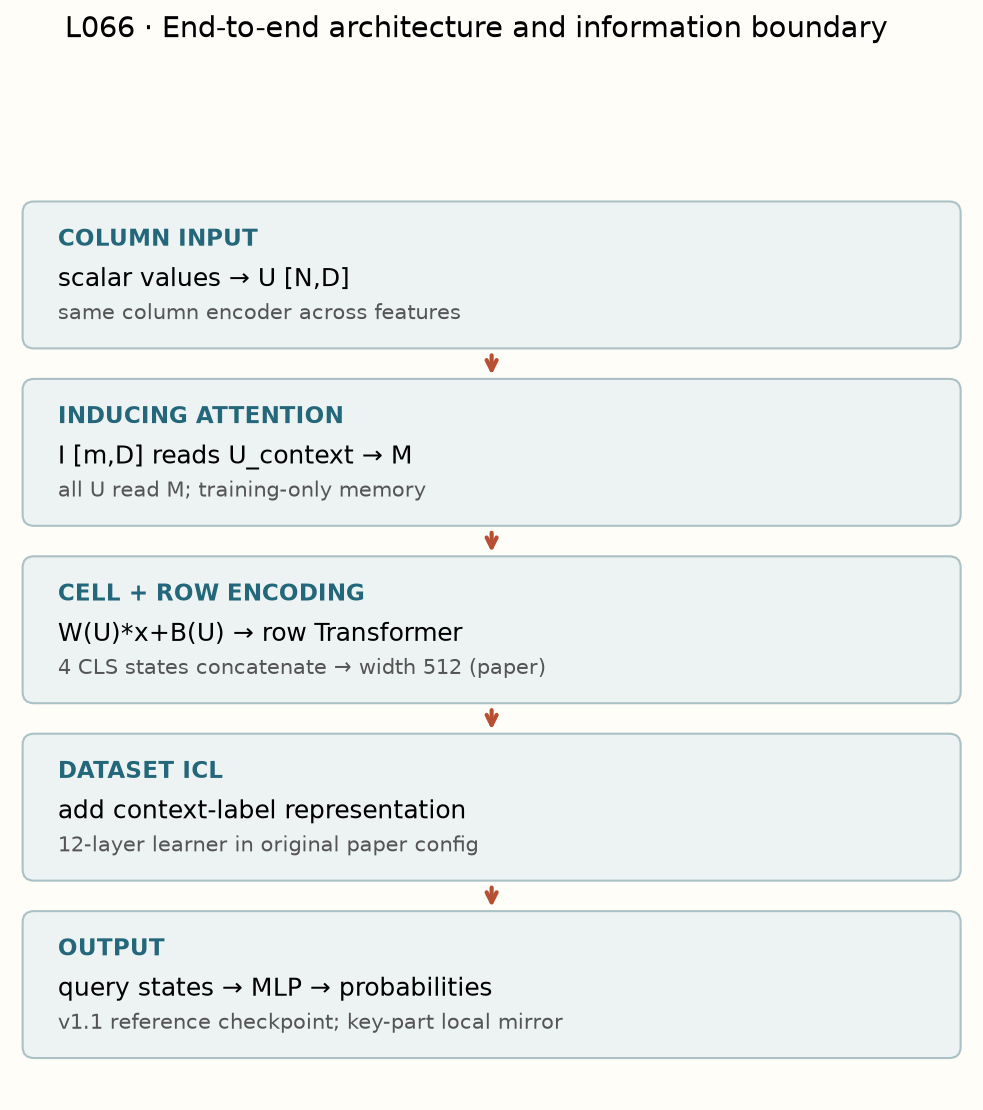</div>

*L066 architecture: worked computation; see adjacent explanation. Scroll wide figures horizontally on small screens.*

## Compress a column through inducing vectors

Let U be the hidden vectors of a column's N scalar values and I be m learned inducing vectors. First compute `M = Attention(I, U_context, U_context)`. Each inducing vector becomes a weighted summary of the training column. Then compute `V = Attention(U, M, M)`: every input cell reads those summaries. Only context rows supply first-stage keys and values; adding an unrelated query cannot change the summaries read by existing rows. This follows the paper's Equations 4–5, with the complete multihead blocks adding learned projections, residual paths and feed-forward transformations.

<div style="overflow-x:auto;max-width:100%">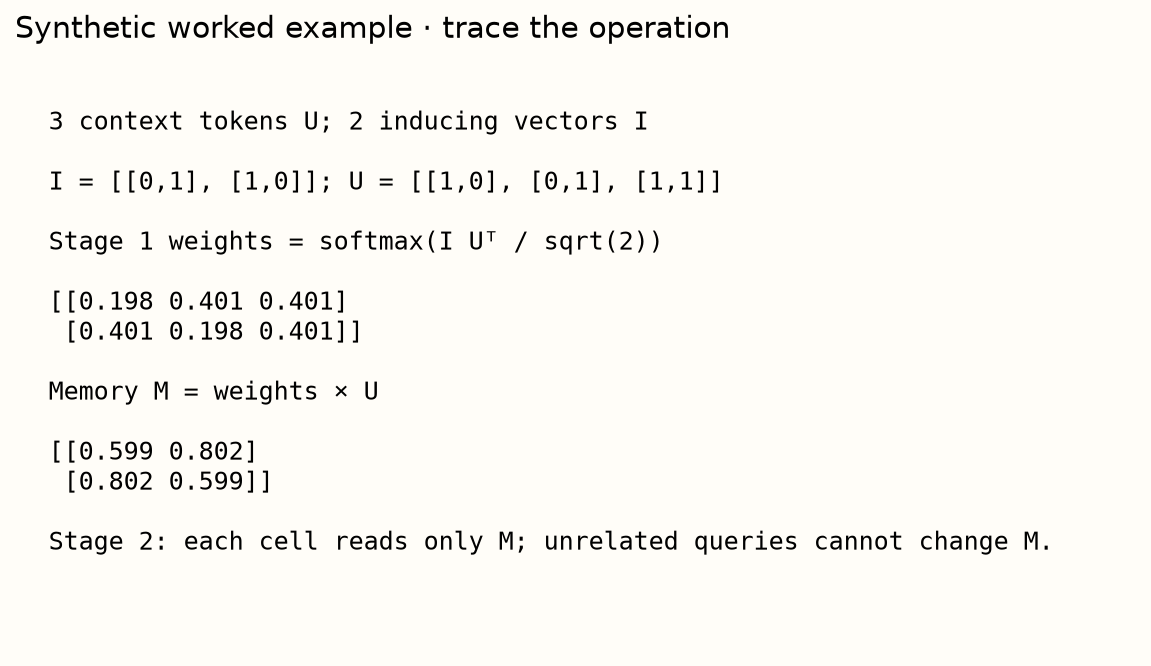</div>

*L066 mechanism: worked computation; see adjacent explanation. Scroll wide figures horizontally on small screens.*

The second stage produces cell-specific information, not one scalar statistic copied to the entire column. Linear heads generate a scale W and offset B for each cell; the embedding is `W*value+B`, coordinate by coordinate. If a value is 2, W is `[.5,−1]` and B is `[.1,.3]`, the resulting vector is `[1.1,−1.7]`. W and B depend on the column context; they are not globally fixed per-feature parameters. The lab keeps the two operations separate so you can check both the information boundary and the arithmetic.

## What becomes cheaper, and what remains quadratic?

Full self-attention over N rows forms N² scores per head. Inducing attention uses roughly `m*C + N*m` scores for one column, where C is context length. With fixed m this column stage grows linearly in row count. But the final dataset-level learner still contains context attention. Calling the entire method “linear attention” would erase that remaining cost.

The cost exhibits in lessons 64 and 70 display column, row and dataset score-element counts separately, holding feature count and inducing count explicit. These are accounting identities for a simplified attention layout, not a peak-memory estimator. The paper's efficient inference also uses batching and memory-management techniques. Measure actual runtime and memory before claiming a hardware ceiling.

## Feature symmetry has a trade-off

If row attention treats equally distributed columns as indistinguishable, different rows that permute those feature values can collapse to similar representations. TabICL uses rotary positional embeddings in row attention to distinguish feature positions. RoPE rotates query/key coordinates by position-dependent angles; this introduces an ordering signal. Ensembling over column permutations can reduce sensitivity, but it is not exact feature-permutation invariance for one fixed view. [Paper Section 3.3](https://arxiv.org/html/2502.05564v1#S3.SS3).

This is a useful correction to “tables have no natural feature order, so any ordering signal is wrong.” Columns also have identities. A suitable model must represent those identities without making arbitrary serialization choices dominate prediction. Your architecture trace should explain both the symmetry goal and the symmetry-breaking device.

<div style="overflow-x:auto;max-width:100%">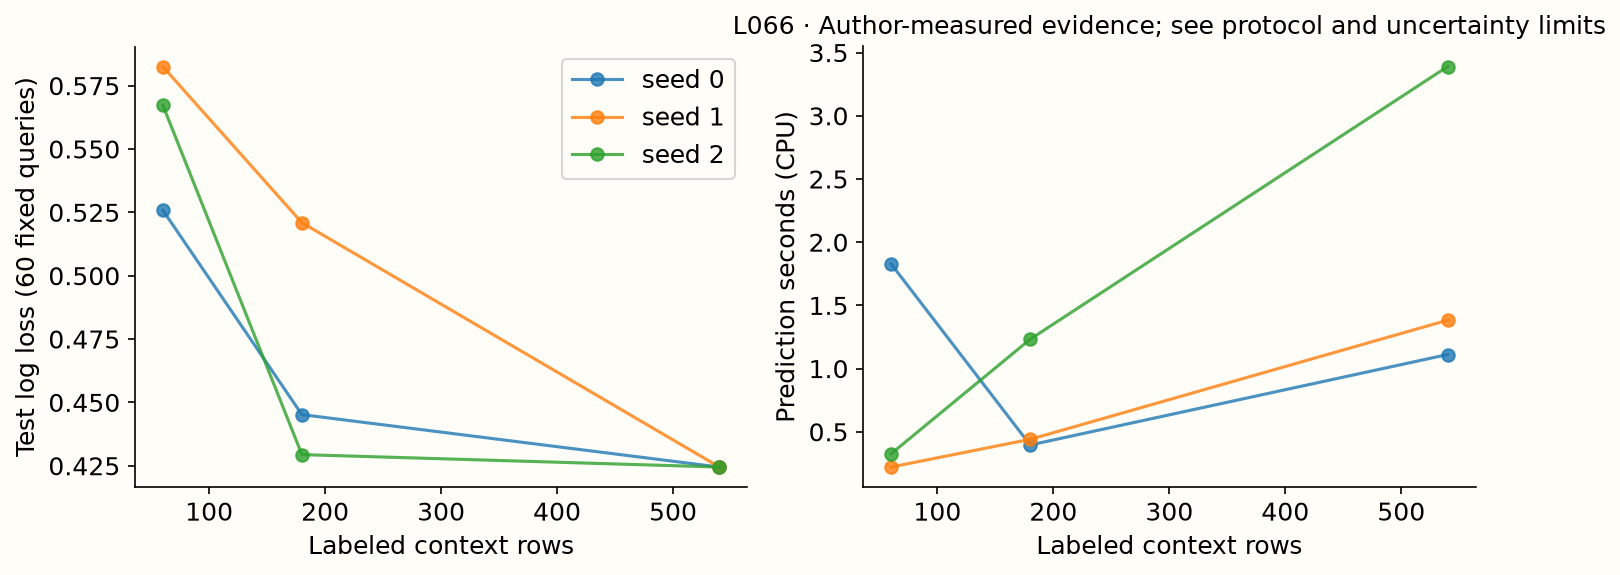</div>

*L066 results: author-reference measurements, separate from your kernel. Scroll wide figures horizontally on small screens.*

## Exit: explain the bottleneck you measured

Implement the two attention stages and conditional affine map. Change an unrelated query and prove that existing cell outputs remain fixed. Then measure nested contexts of 60, 180 and 540 labeled rows with the same query rows, checkpoint and one-view setting. Report accuracy/log loss and context-preparation versus prediction time across seeds; do not turn this one-task scale intervention into a universal accuracy comparison.

Use the five-dataset checkpoint evidence for broader comparisons. State which part of the architecture you implemented, which pretrained version produced measurements, and which large-context result remains a cited paper claim. Explain why a retrieval method and an inducing-vector method reduce different costs even though both summarize a large context.

## Reproduction contract and task support

The visible code below implements the named operator or reduced architecture. The full pretrained model is a separately pinned reference path. Real public-table experiments use Tier A data; synthetic coin/SCM/shift tasks are Tier C mechanism isolation. Seeds, row identities, recipe budgets, versions and source/checkpoint hashes are available in the linked contract and evidence. Numerical agreement with a local operator is not a paper-table reproduction.

In [ ]:
# PROVIDED — environment, peripheral data/metric utilities
import os, sys, math, copy, re, json, hashlib, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from scipy.stats import rankdata, friedmanchisquare, studentized_range, t
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.model_selection import StratifiedKFold
from threadpoolctl import threadpool_limits
from IPython.display import display
for directory in [Path.cwd(), Path.cwd()/'labs', Path.cwd().parent]:
    if (directory/'relkit').is_dir():
        ROOT=directory.resolve(); sys.path.insert(0,str(ROOT)); break
else:
    raise RuntimeError('Run the Colab bootstrap or start in the course repository')
torch.set_num_threads(1)
from relkit.foundation_benchmark import random_task, encode_train
print('CPU mechanism track; official checkpoint reruns use an isolated subprocess after EXIT.')

In [ ]:
# PROVIDED — attention; inspect the live function calls
def attention(q, k, v, allowed=None):
    """Scaled dot-product attention; True means allowed (PyTorch SDPA convention)."""
    scores = q @ k.transpose(-1, -2) / math.sqrt(q.shape[-1])
    if allowed is not None:
        if not allowed.any(dim=-1).all():
            raise ValueError('Each query needs an allowed key')
        scores = scores.masked_fill(~allowed, float('-inf'))
    return scores.softmax(-1) @ v

## TODO 1 · induced_column

**Goal:** Compress training keys/values into inducing summaries, then let every cell read those summaries.

**Why it matters:** a wrong implementation can produce a plausible-looking experiment while violating this lesson's prediction contract. Before coding, name one input that should fail or one intervention that should leave the result unchanged.

**Hint boundary:** reason from the worked example and the function contract; the CHECK verifies behavior, not a required code layout.

In [ ]:
# TODO 1 — induced_column
def induced_column(tokens, inducing, n_context):
    raise NotImplementedError("Implement the stated operation")

In [ ]:
# CHECK 1 — induced_column
torch.manual_seed(66);u=torch.randn(7,8);inducing=torch.randn(3,8)
base=induced_column(u,inducing,4);changed=u.clone();changed[5:]=1000
torch.testing.assert_close(base[:5],induced_column(changed,inducing,4)[:5])
assert base.shape==u.shape

print("PASS: induced_column")

## TODO 2 · distribution_embedding

**Goal:** Use the induced cell states to generate W and B, then form a per-cell affine embedding.

**Why it matters:** a wrong implementation can produce a plausible-looking experiment while violating this lesson's prediction contract. Before coding, name one input that should fail or one intervention that should leave the result unchanged.

**Hint boundary:** reason from the worked example and the function contract; the CHECK verifies behavior, not a required code layout.

In [ ]:
# TODO 2 — distribution_embedding
def distribution_embedding(values, tokens, inducing, n_context, weight_head, bias_head):
    raise NotImplementedError("Implement the stated operation")

In [ ]:
# CHECK 2 — distribution_embedding
u=torch.tensor([[1.,0.],[0.,1.],[1.,1.]])
inducing=torch.eye(2);values=torch.tensor([2.,3.,4.])
out=distribution_embedding(values,u,inducing,2,lambda h:torch.ones_like(h)*.5,lambda h:torch.ones_like(h)*.1)
torch.testing.assert_close(out,torch.tensor([[1.1,1.1],[1.6,1.6],[2.1,2.1]]))

print("PASS: distribution_embedding")

## Run your live implementation

Predict the outcome before execution. This cell calls the functions you just wrote. Changing a TODO must change the corresponding computation or make a CHECK fail. The text printed with the result identifies whether this is a small training run, a mechanism test or a reanalysis of committed measurements.

In [ ]:
# PROVIDED — experiment driven by your live functions
raw,y,reg,audit=random_task('phoneme',cap=120,seed=66);x=encode_train(raw)
values=torch.tensor(np.concatenate([x['train'][:,0],x['test'][:4,0]]),dtype=torch.float32)
torch.manual_seed(66);tokens=nn.Linear(1,8)(values[:,None]);inducing=torch.randn(3,8)
out=distribution_embedding(values,tokens,inducing,len(x['train']),nn.Linear(8,8),nn.Linear(8,8))
assert out.shape==(len(values),8);out.sum().backward()
trial={'cell_output_shape':list(out.shape),'context_rows':len(x['train']),'scope':'untrained distribution-aware column mechanism'};print(trial)

## Audit author-reference evidence

Inspect the measured results below independently of your smoke experiment. A fresh smoke may use a smaller budget. Preserve the protocol difference rather than forcing numerical agreement with a different run. The committed prediction arrays let you reconstruct scores without downloading pretrained weights.

In [ ]:
# PROVIDED — readable evidence, never impersonating current-kernel training
author=json.loads((ROOT/'_verify_l066_results.json').read_text())
print('AUTHOR REFERENCE:',author.get('scope',author.get('note','Declared checkpoint experiment')))
print('Evidence verdict:',author.get('verdict'))
rows=author.get('records',author.get('summary',[]))
if isinstance(rows,list) and rows:
    display(pd.DataFrame(rows).drop(columns=['predictions','targets','history','context_ids','task_losses'],errors='ignore').head(24))
if 66 in [60,70]:
    for regime,summary in author['summary'].items():
        print(regime,summary['mean_ranks'],'Friedman p=',summary['friedman_p'],'CD=',summary['nemenyi_cd'])

## EXIT TICKET · submit an executable argument

Provide your code output plus a 30–100 word verdict: which implementation ran, what information it could use, what evidence supports the result, and which paper claim remains untested. Include an unexpected or failed case and a next discriminating experiment. The length check below only enforces an attempt; the tutor grades your reasoning. Do not infer personal mastery from a green code cell.

In [ ]:
# TODO — written verdict; paste the resulting artifact and explanation to the tutor
verdict=''
assert len(verdict.split())>=30, 'Write a defensible verdict; a passing code cell is not the explanation'
ticket={'lesson':66,'checks':'passed in this kernel','trial':trial,'verdict':verdict,
        'paper_reproduction':'NOT_ESTABLISHED','author_reference':'_verify_l066_results.json'}
folder=ROOT/'data/cache/foundation';folder.mkdir(parents=True,exist_ok=True)
path=folder/'student-l066-exit.json'
path.write_text(json.dumps(ticket,indent=2,default=lambda x:x.item() if hasattr(x,'item') else x.tolist(),allow_nan=False)+'\n')
print('EXIT artifact:',path)

## NEXT STEP · reproduce or scale the declared track

Read [the exact reproduction contract](l066-reproduction.md) before increasing resources. The gate below invokes the shared runner in a subprocess; historical versions are installed into isolated package directories so v1 and v2 cannot silently replace one another. It may download the pinned checkpoint. Larger runs remain INCOMPARABLE wherever material paper-protocol gaps remain. A full paper preset deliberately fails until the original protocol is implemented.

For unattended CPU execution: `modal run --detach modal/foundation_repro.py --lesson 66 --preset closer`. This is a supplied operator, not evidence that a cloud job was run.

In [ ]:
# PROVIDED — explicit post-EXIT gate (OFF by default)
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:
    import subprocess
    subprocess.run([sys.executable,str(ROOT/'_run_foundation.py'),'--lesson','66',
                    '--preset','closer','--output',str(ROOT/'data/cache/foundation/l066-closer.json')],check=True)
else:
    print('Scale-up NOT_RUN in this kernel. See the protocol ledger before enabling.')